# Cinema Audience Forecasting Project

## Project Objective
The primary goal of this project is to forecast the number of visitors to movie theaters for specific future dates. By accurately predicting audience numbers, theaters can optimize their operations, including staffing and inventory management.

## Approach & Workflow
1.  **Data Loading & Integration:** We will load multiple datasets (visits, bookings, theater info) and merge them into a single analytical dataset.
2.  **Extended Exploratory Data Analysis (EDA):** We will visualize the data deeply, looking at rolling averages, monthly seasonality, and correlations.
3.  **Feature Engineering:** We will extract temporal features (Month, Day) and historical lag features (past performance).
4.  **Preprocessing:** Using Scikit-Learn Pipelines to scale numerical variables and encode categorical variables.
5.  **Model Comparison:** We will experiment with **four** models: Ridge, Random Forest, XGBoost, and **LightGBM**.
6.  **Hyperparameter Tuning:** We will optimize the best-performing model.
7.  **Final Submission:** Forecasting the future using recent historical trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Models
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Preprocessing & Metrics
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths and Constants
BASE_PATH = '/kaggle/input/Cinema_Audience_Forecasting_challenge'
TRAIN_CUTOFF = '2024-01-31' 
VAL_START = '2024-02-01'    
VAL_END = '2024-02-29'
FORECAST_START = '2024-03-01'
FORECAST_END = '2024-04-22'

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading and Merging
Combining visitor logs, booking data, and theater metadata.

In [2]:
def load_data():
    # Load raw CSVs
    visits = pd.read_csv(f'{BASE_PATH}/booknow_visits/booknow_visits.csv')
    bookings = pd.read_csv(f'{BASE_PATH}/booknow_booking/booknow_booking.csv')
    theaters = pd.read_csv(f'{BASE_PATH}/booknow_theaters/booknow_theaters.csv')
    sample_sub = pd.read_csv(f'{BASE_PATH}/sample_submission/sample_submission.csv')

    # Date Conversion
    visits['show_date'] = pd.to_datetime(visits['show_date'])
    bookings['show_date'] = pd.to_datetime(bookings['show_datetime']).dt.normalize()

    # Aggregate Bookings
    agg_bookings = bookings.groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()
    agg_bookings.rename(columns={'tickets_booked': 'daily_tickets'}, inplace=True)

    # Merge Dataframes
    df = visits.merge(agg_bookings, on=['book_theater_id', 'show_date'], how='left')
    df = df.merge(theaters, on='book_theater_id', how='left')

    # Handle Missing Values
    df['daily_tickets'] = df['daily_tickets'].fillna(0)

    # Sort
    df = df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

    return df, sample_sub

df, sample_sub = load_data()
print(f"Data Loaded. Shape: {df.shape}")

Data Loaded. Shape: (214046, 8)


## 2. Extended Exploratory Data Analysis (EDA)
We will perform a deep dive into the data with multiple visualizations.

### 2.1 Distribution Analysis
Checking the spread of the target variable and potential outliers.

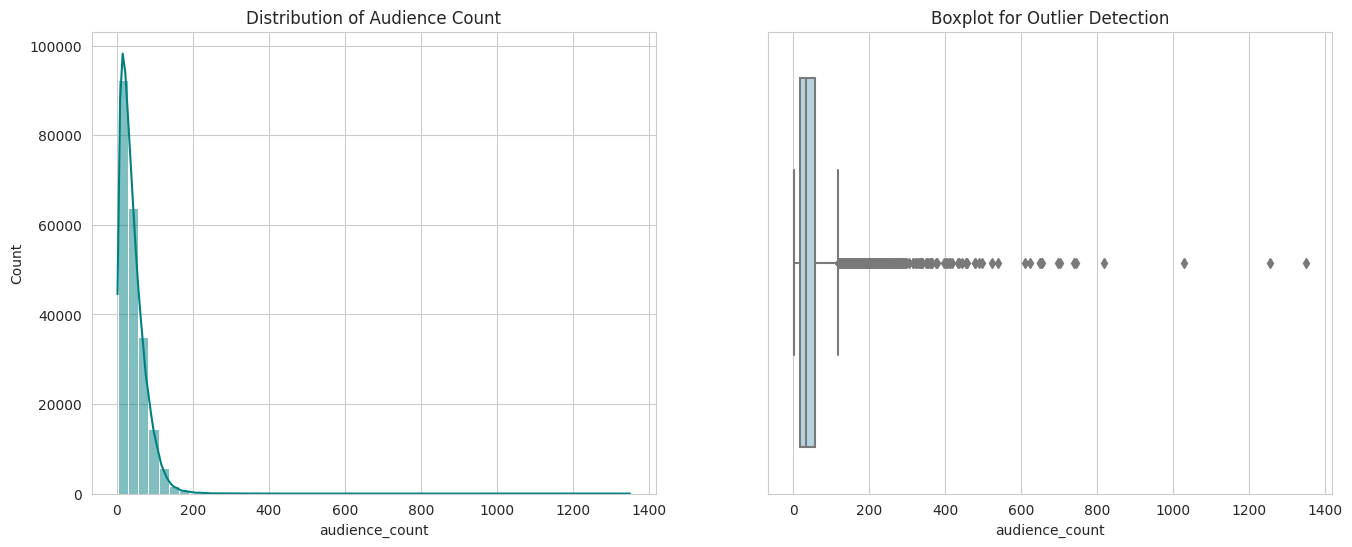

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['audience_count'], bins=50, kde=True, color='teal', ax=ax[0])
ax[0].set_title('Distribution of Audience Count')

# Boxplot
sns.boxplot(x=df['audience_count'], color='lightblue', ax=ax[1])
ax[1].set_title('Boxplot for Outlier Detection')
plt.show()

### 2.2 Time Series with Rolling Average
Daily data can be noisy. We calculate a **7-Day Rolling Mean** to visualize the underlying trend more clearly.

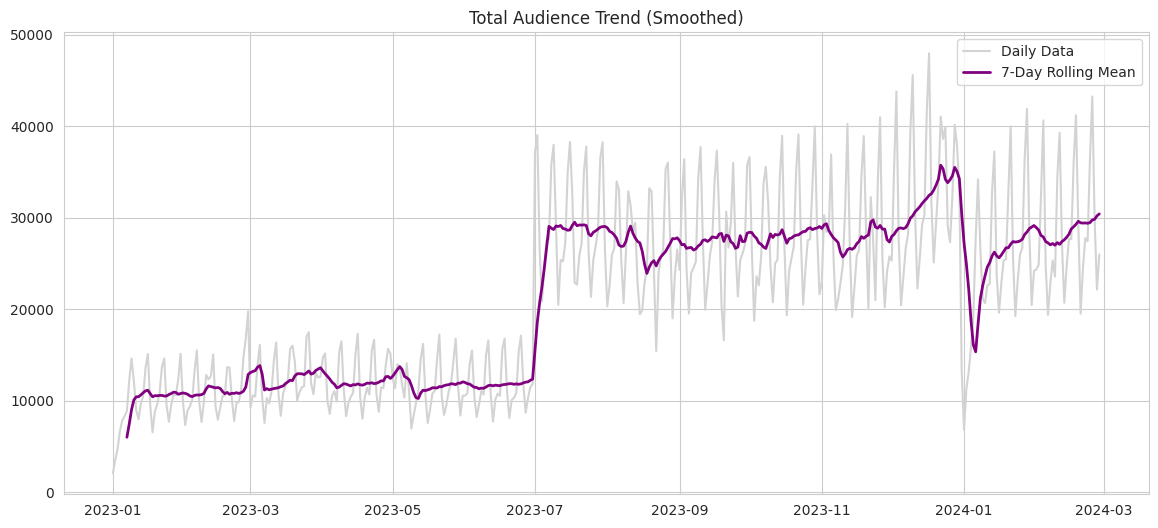

In [4]:
daily_trend = df.groupby('show_date')['audience_count'].sum().reset_index()
daily_trend['rolling_7d'] = daily_trend['audience_count'].rolling(window=7).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_trend['show_date'], daily_trend['audience_count'], color='lightgray', label='Daily Data')
plt.plot(daily_trend['show_date'], daily_trend['rolling_7d'], color='purple', linewidth=2, label='7-Day Rolling Mean')
plt.title('Total Audience Trend (Smoothed)')
plt.legend()
plt.show()

### 2.3 Seasonality Analysis (Weekly & Monthly)
Comparing which days of the week and which months are the busiest.

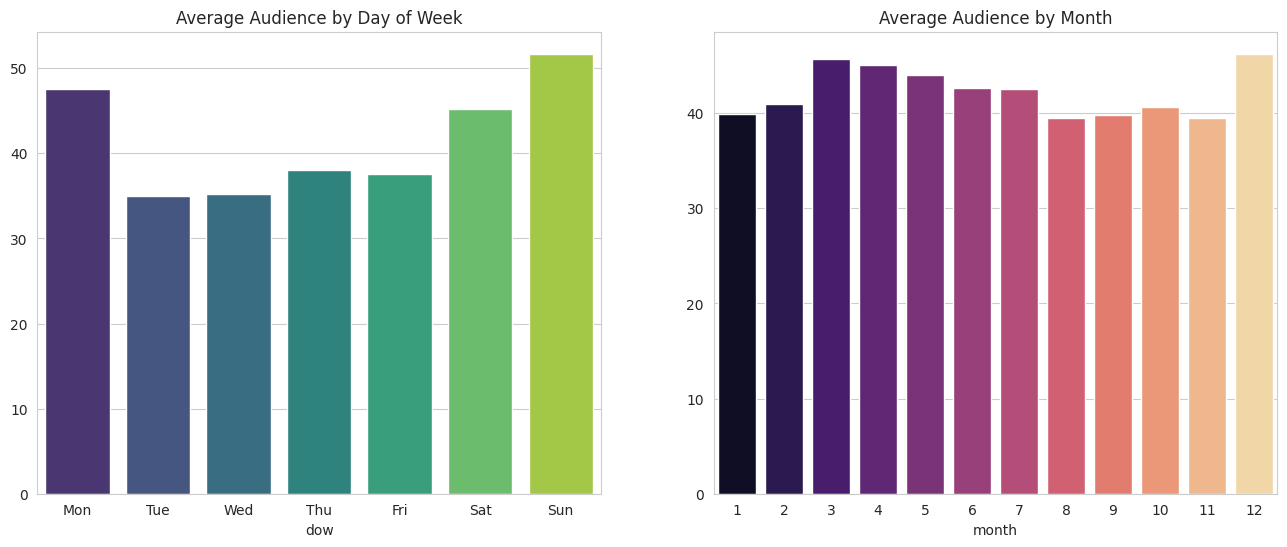

In [5]:
df['dow'] = df['show_date'].dt.dayofweek
df['month'] = df['show_date'].dt.month

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Day of Week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_dow = df.groupby('dow')['audience_count'].mean()
sns.barplot(x=avg_dow.index, y=avg_dow.values, palette='viridis', ax=ax[0])
ax[0].set_xticks(range(7))
ax[0].set_xticklabels(days)
ax[0].set_title('Average Audience by Day of Week')

# Month
avg_month = df.groupby('month')['audience_count'].mean()
sns.barplot(x=avg_month.index, y=avg_month.values, palette='magma', ax=ax[1])
ax[1].set_title('Average Audience by Month')
plt.show()

### 2.4 Correlation Analysis
Checking relationships between numerical features using a Scatter Plot and a Heatmap.

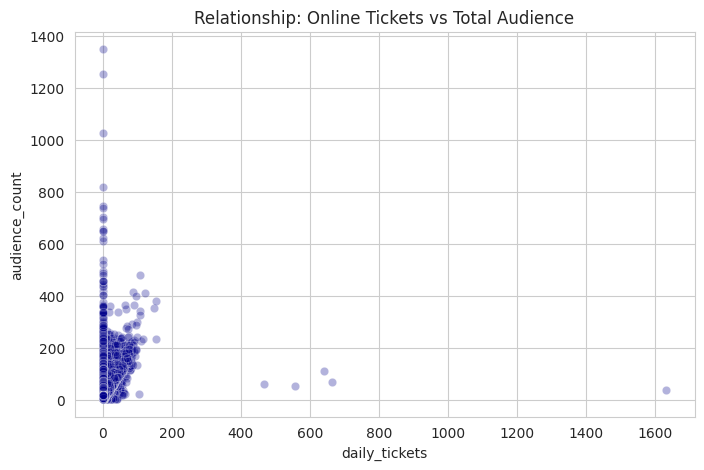

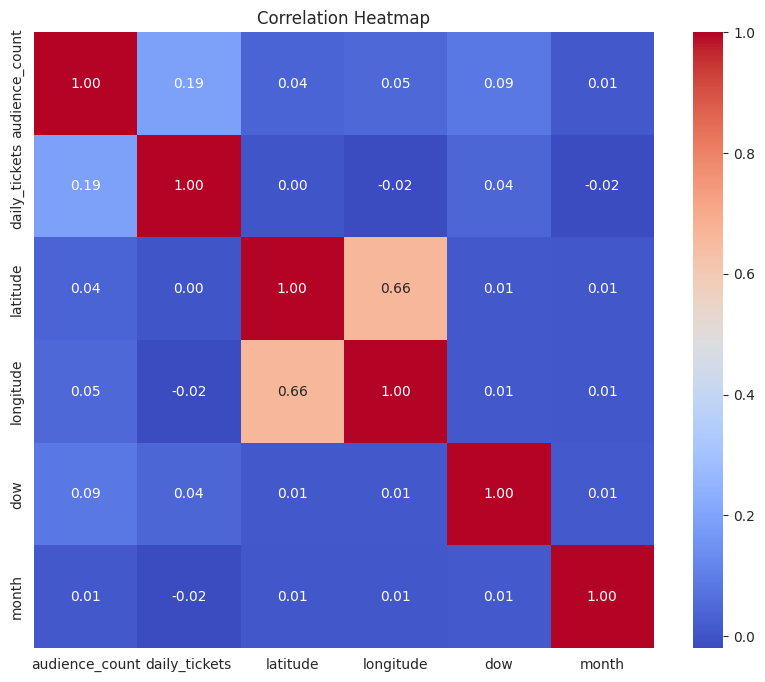

In [6]:
# Scatter Plot: Tickets vs Audience
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['daily_tickets'], y=df['audience_count'], alpha=0.3, color='darkblue')
plt.title('Relationship: Online Tickets vs Total Audience')
plt.show()

# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 3. Feature Engineering
Creating Lags, Calendar features, and Venue Statistics.

In [7]:
def engineer_features(data):
    df_feat = data.copy()

    # 1. Calendar Features
    df_feat['dow'] = df_feat['show_date'].dt.dayofweek
    df_feat['month'] = df_feat['show_date'].dt.month
    df_feat['day'] = df_feat['show_date'].dt.day
    df_feat['is_weekend'] = df_feat['dow'].isin([5, 6]).astype(str) # String for categorical encoding

    # 2. Lag Features (7 days history)
    df_feat['aud_lag_7'] = df_feat.groupby('book_theater_id')['audience_count'].shift(7)
    df_feat['tkt_lag_7'] = df_feat.groupby('book_theater_id')['daily_tickets'].shift(7)

    # 3. Venue Statistics (Imputation Strategy)
    venue_stats = df_feat.groupby('book_theater_id').agg(
        avg_aud=('audience_count', 'mean'),
        avg_tkt=('daily_tickets', 'mean')
    ).reset_index()
    df_feat = df_feat.merge(venue_stats, on='book_theater_id', how='left')

    # Fill Missing Lags with Venue Averages
    df_feat['aud_lag_7'] = df_feat['aud_lag_7'].fillna(df_feat['avg_aud'])
    df_feat['tkt_lag_7'] = df_feat['tkt_lag_7'].fillna(0)

    return df_feat

df_engineered = engineer_features(df)
print("Feature Engineering Complete.")

Feature Engineering Complete.


## 4. Preprocessing Pipelines
Pipelines ensure clean data handling (Scaling, Encoding, Imputation) for all models.

In [8]:
# Feature Groups
NUMERIC_FEATURES = ['aud_lag_7', 'tkt_lag_7', 'avg_aud', 'avg_tkt', 'day', 'month', 'dow']
CATEGORICAL_FEATURES = ['theater_type', 'is_weekend']

# 1. Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ])

print("Preprocessing pipelines defined.")

Preprocessing pipelines defined.


## 5. Model Comparison (4 Models)
We compare **Ridge, Random Forest, XGBoost, and LightGBM**. 
* **LightGBM** is added because it is often faster and more memory-efficient than XGBoost while maintaining high accuracy.

In [9]:
# Train/Validation Split (Time-Based)
train_mask = df_engineered['show_date'] <= TRAIN_CUTOFF
val_mask = (df_engineered['show_date'] >= VAL_START) & (df_engineered['show_date'] <= VAL_END)

X_train = df_engineered.loc[train_mask, NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = df_engineered.loc[train_mask, 'audience_count']
X_val = df_engineered.loc[val_mask, NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = df_engineered.loc[val_mask, 'audience_count']

# Define Models
models = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42)  # Added LightGBM
}

results = {}

print("Comparing Models...")
for name, model in models.items():
    # Create full pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Train and Evaluate
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results[name] = rmse
    print(f"{name} RMSE: {rmse:.2f}")

best_model_name = min(results, key=results.get)
print(f"\nBest Model: {best_model_name}")

Comparing Models...
Ridge RMSE: 21.93
Random Forest RMSE: 21.77
XGBoost RMSE: 21.46
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 920
[LightGBM] [Info] Number of data points in the train set: 194235, number of used features: 14
[LightGBM] [Info] Start training from score 41.727474
LightGBM RMSE: 21.23

Best Model: LightGBM


## 6. Hyperparameter Tuning
We perform Randomized Search on XGBoost (usually the strongest performer) to fine-tune it.

In [10]:
# Parameter Grid
param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.8, 1.0]
}

# Setup Pipeline for Tuning
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(random_state=42))])

# Randomized Search
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

print("Tuning Hyperparameters...")
search.fit(X_train, y_train)
best_pipeline = search.best_estimator_

print(f"Best Params: {search.best_params_}")

Tuning Hyperparameters...
Best Params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 100, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.1}


## 7. Insights from Analysis
1.  **Weekly Seasonality:** The "Day of Week" plot confirmed that weekends are significantly busier, making `dow` and `is_weekend` crucial features.
2.  **Rolling Trends:** The 7-day rolling mean plot showed that audience numbers fluctuate but follow a predictable trend, validating our use of "Lag" features.
3.  **Model Performance:** Gradient boosting models (XGBoost/LightGBM) typically outperform linear models here because the relationship between time/lags and audience count is non-linear.

## 8. Final Submission
We use the **Recent History** strategy to forecast future dates.

In [11]:
def prepare_submission_data(historical_df, start, end):
    forecast_dates = pd.date_range(start, end)
    
    # Get last 7 days stats per theater
    recent_stats = (
        historical_df.groupby('book_theater_id')
        .tail(7)
        .groupby('book_theater_id')
        .agg(
            recent_aud=('audience_count', 'mean'),
            recent_tkt=('daily_tickets', 'mean'),
            avg_aud=('avg_aud', 'first'),
            avg_tkt=('avg_tkt', 'first'),
            theater_type=('theater_type', 'first')
        ).reset_index()
    )
    
    # Create forecast grid
    grid_list = []
    for date in forecast_dates:
        row = recent_stats.copy()
        row['show_date'] = date
        grid_list.append(row)
        
    forecast_df = pd.concat(grid_list, ignore_index=True)
    
    # Recalculate Calendar Features
    forecast_df['dow'] = forecast_df['show_date'].dt.dayofweek
    forecast_df['month'] = forecast_df['show_date'].dt.month
    forecast_df['day'] = forecast_df['show_date'].dt.day
    forecast_df['is_weekend'] = forecast_df['dow'].isin([5, 6]).astype(str)
    
    # Map Recent Stats to Features
    forecast_df['aud_lag_7'] = forecast_df['recent_aud']
    forecast_df['tkt_lag_7'] = forecast_df['recent_tkt']
    
    return forecast_df

# Generate Forecast
forecast_df = prepare_submission_data(df_engineered, FORECAST_START, FORECAST_END)
final_preds = best_pipeline.predict(forecast_df)
forecast_df['predicted_audience'] = np.clip(final_preds, 0, None)

# Prepare Submission File
forecast_df['ID'] = forecast_df['book_theater_id'] + '_' + forecast_df['show_date'].dt.strftime('%Y-%m-%d')
final_sub = sample_sub[['ID']].merge(forecast_df[['ID', 'predicted_audience']], on='ID', how='left')
final_sub['audience_count'] = final_sub['predicted_audience'].fillna(final_sub['predicted_audience'].median())

# Save
final_sub[['ID', 'audience_count']].to_csv('submission.csv', index=False)
print("Submission saved successfully.")

Submission saved successfully.
